In [2]:
import optuna
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

1. Load artifacts:

In [3]:
X_train_xgb = joblib.load('../models/X_train_xgb.pkl')
X_test_xgb = joblib.load('../models/X_test_xgb.pkl')

y_train_xgb = joblib.load('../models/y_train_xgb.pkl')
y_test_xgb = joblib.load('../models/y_test_xgb.pkl')

smote_xgb_model = joblib.load(
    '../models/smote_xgb_model.pkl'
)

2. Extracting preprocessor:

In [4]:
fe_preprocessor = (
    smote_xgb_model
    .named_steps['preprocessor']
)

3. Building Objective Function:

In [5]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            500
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),

        'gamma': trial.suggest_float(
            'gamma',
            0,
            5
        ),

        'min_child_weight': trial.suggest_int(
            'min_child_weight',
            1,
            10
        )
    }

# Pipeline:

    model = ImbPipeline(
        steps=[
            ('preprocessor', fe_preprocessor),

            ('smote', SMOTE(
                random_state=42
            )),

            ('model', XGBClassifier(
                random_state=42,
                objective='multi:softprob',
                num_class=3,
                eval_metric='mlogloss',
                **params
            ))
        ]
    )

    model.fit(
        X_train_xgb,
        y_train_xgb
    )

    preds = model.predict(
        X_test_xgb
    )

    score = f1_score(
        y_test_xgb,
        preds,
        average='macro'
    )

    return score

4. Run Optuna:

In [6]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-06-29 22:44:17,099] A new study created in memory with name: no-name-98aba7aa-c812-4249-9eb0-21ee59b3f700
[I 2026-06-29 22:44:20,381] Trial 0 finished with value: 0.7940682295377002 and parameters: {'n_estimators': 270, 'max_depth': 8, 'learning_rate': 0.15763456836346057, 'subsample': 0.6402977316119526, 'colsample_bytree': 0.809760187434864, 'gamma': 4.113881857687357, 'min_child_weight': 8}. Best is trial 0 with value: 0.7940682295377002.
[I 2026-06-29 22:44:20,729] Trial 1 finished with value: 0.7797784019975031 and parameters: {'n_estimators': 271, 'max_depth': 6, 'learning_rate': 0.2968167401930039, 'subsample': 0.9437884782224764, 'colsample_bytree': 0.6253534431982474, 'gamma': 2.068120855661368, 'min_child_weight': 2}. Best is trial 0 with value: 0.7940682295377002.
[I 2026-06-29 22:44:21,261] Trial 2 finished with value: 0.7855292483225443 and parameters: {'n_estimators': 365, 'max_depth': 9, 'learning_rate': 0.06612325255526066, 'subsample': 0.7902880645351603, 'cols

In [7]:
study.best_value

0.8005557033489993

In [8]:
study.best_value

0.8005557033489993

5. Training final tuned model:

In [9]:
best_params = study.best_params

In [10]:
X_train_xgb.shape

(784, 14)

Optimization history:

C:\Users\kadit\AppData\Local\Temp\ipykernel_9816\357126150.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(


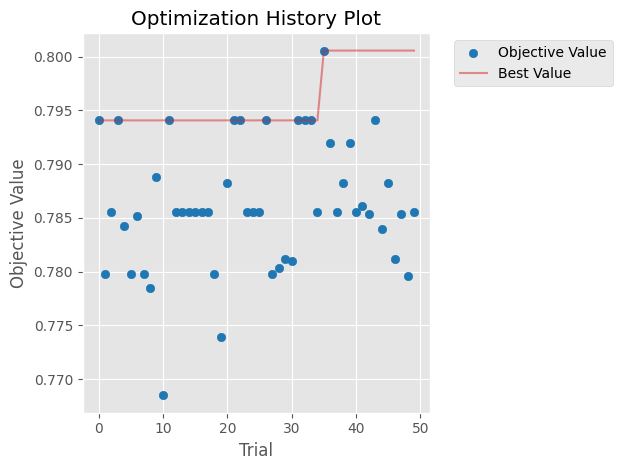

In [11]:
optuna.visualization.matplotlib.plot_optimization_history(
    study
)

plt.show()

Optuna found good parameter regions early, and further searching produced only marginal improvements.

Parameter Importance:

C:\Users\kadit\AppData\Local\Temp\ipykernel_9816\1020437608.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(


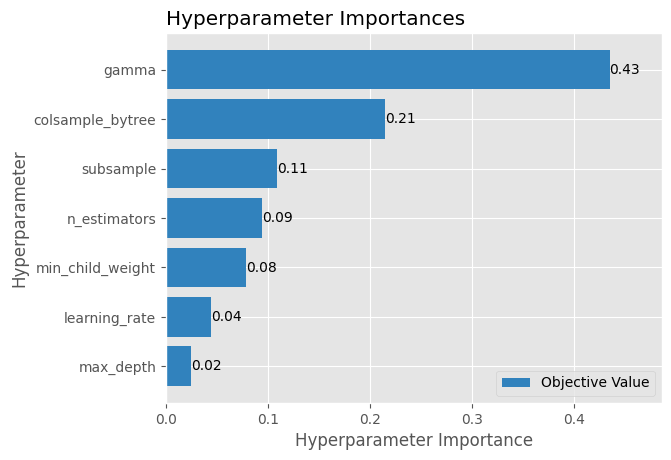

In [12]:
optuna.visualization.matplotlib.plot_param_importances(
    study
)

plt.show()

Gamma controls:

Minimum loss reduction required before creating a split.

Higher gamma:

- fewer splits
- simpler trees
- less overfitting

Hyperparameter importance analysis revealed that gamma had the largest impact on model performance, indicating that preventing overfitting was more important than increasing model complexity.

In [13]:
best_params = study.best_params
best_params

{'n_estimators': 267,
 'max_depth': 10,
 'learning_rate': 0.11604368345086422,
 'subsample': 0.6209015706906675,
 'colsample_bytree': 0.6063302062680628,
 'gamma': 3.8237773703863125,
 'min_child_weight': 3}

The 'objective model' that we created ,exists only inside the function. It's a local variable.

After Optuna finishes, Python destroys that object as its for trial purpose.

Therefore, we must build the model again outside the objective function.

# Building final tuned model:

In [15]:
tuned_xgb_model = ImbPipeline(
    steps=[
        ('preprocessor', fe_preprocessor),

        ('smote',
         SMOTE(random_state=42)
        ),

        ('model',
         XGBClassifier(
             random_state=42,
             objective='multi:softprob',
             num_class=3,
             eval_metric='mlogloss',
             **best_params
         )
        )
    ]
)

In [16]:
tuned_xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [17]:
joblib.dump(
    tuned_xgb_model,
    '../models/tuned_xgb_model.pkl'
)

['../models/tuned_xgb_model.pkl']